# Ex2 — NLP 67658

In [1]:
# Shared imports + reproducibility + hyperparameters + helpers
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from ex2 import get_data, category_dict, transformer_classification
categories = list(category_dict.keys())

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available()
                      else ('mps' if torch.backends.mps.is_available() else 'cpu'))

# Q1/Q2 hyperparameters
epochs = 20
batch_size = 16
lr = 1e-3
feature_dim = 2000
hidden_dim = 500
num_labels = len(category_dict)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_labels),
        )
    def forward(self, x):
        return self.net(x)

def train_and_eval(model, train_loader, test_loader, optimizer, criterion, epochs, device):
    train_losses, val_accs = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_losses.append(running / n)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_accs.append(correct / total)
        print(f'Epoch {epoch:02d} | train loss {train_losses[-1]:.4f} | val acc {val_accs[-1]:.4f}')
    return train_losses, val_accs

print(f'device: {device}')


device: mps


# Q1 — Log-linear classifier (TFIDF + single-layer perceptron)

## Q1 (a) portion=0.1

In [2]:
# Data + TFIDF (portion=0.1)
portion = 0.1
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 229, test size: 1508


In [3]:
# Train log-linear (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q1_train_losses_a, q1_val_accs_a = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3823 | val acc 0.4741
Epoch 02 | train loss 1.3564 | val acc 0.5477
Epoch 03 | train loss 1.3331 | val acc 0.5862
Epoch 04 | train loss 1.3106 | val acc 0.6008
Epoch 05 | train loss 1.2884 | val acc 0.6207
Epoch 06 | train loss 1.2666 | val acc 0.6280
Epoch 07 | train loss 1.2452 | val acc 0.6466
Epoch 08 | train loss 1.2246 | val acc 0.6459
Epoch 09 | train loss 1.2037 | val acc 0.6618
Epoch 10 | train loss 1.1837 | val acc 0.6691
Epoch 11 | train loss 1.1641 | val acc 0.6790
Epoch 12 | train loss 1.1443 | val acc 0.6870
Epoch 13 | train loss 1.1256 | val acc 0.6890
Epoch 14 | train loss 1.1064 | val acc 0.6936
Epoch 15 | train loss 1.0886 | val acc 0.7009
Epoch 16 | train loss 1.0704 | val acc 0.7029
Epoch 17 | train loss 1.0528 | val acc 0.7115
Epoch 18 | train loss 1.0351 | val acc 0.7129
Epoch 19 | train loss 1.0183 | val acc 0.7115
Epoch 20 | train loss 1.0016 | val acc 0.7142


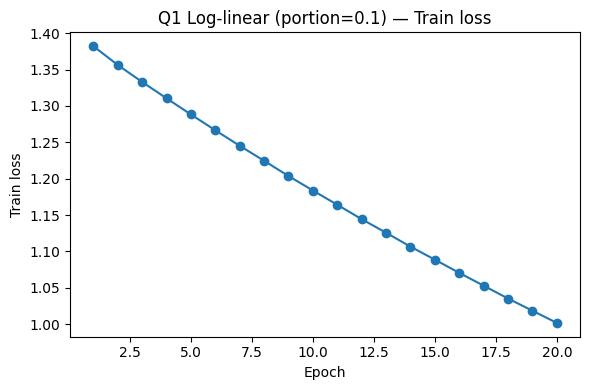

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_train_losses_a) + 1), q1_train_losses_a, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q1 Log-linear (portion=0.1) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


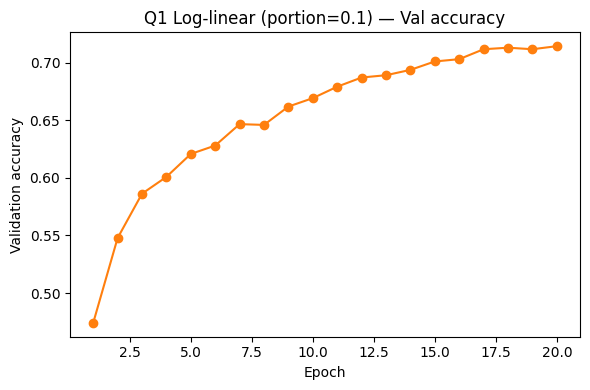

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_val_accs_a) + 1), q1_val_accs_a, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q1 Log-linear (portion=0.1) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q1 (b) portion=0.2

In [6]:
# Data + TFIDF (portion=0.2)
portion = 0.2
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 451, test size: 1508


In [7]:
# Train log-linear (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q1_train_losses_b, q1_val_accs_b = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3755 | val acc 0.6167
Epoch 02 | train loss 1.3382 | val acc 0.6479
Epoch 03 | train loss 1.3043 | val acc 0.6094
Epoch 04 | train loss 1.2714 | val acc 0.6214
Epoch 05 | train loss 1.2399 | val acc 0.6393
Epoch 06 | train loss 1.2085 | val acc 0.6943
Epoch 07 | train loss 1.1788 | val acc 0.6976
Epoch 08 | train loss 1.1498 | val acc 0.7003
Epoch 09 | train loss 1.1218 | val acc 0.6963
Epoch 10 | train loss 1.0948 | val acc 0.7049
Epoch 11 | train loss 1.0680 | val acc 0.7109
Epoch 12 | train loss 1.0427 | val acc 0.7162
Epoch 13 | train loss 1.0182 | val acc 0.7248
Epoch 14 | train loss 0.9940 | val acc 0.7314
Epoch 15 | train loss 0.9707 | val acc 0.7401
Epoch 16 | train loss 0.9483 | val acc 0.7454
Epoch 17 | train loss 0.9263 | val acc 0.7447
Epoch 18 | train loss 0.9051 | val acc 0.7473
Epoch 19 | train loss 0.8841 | val acc 0.7460
Epoch 20 | train loss 0.8642 | val acc 0.7487


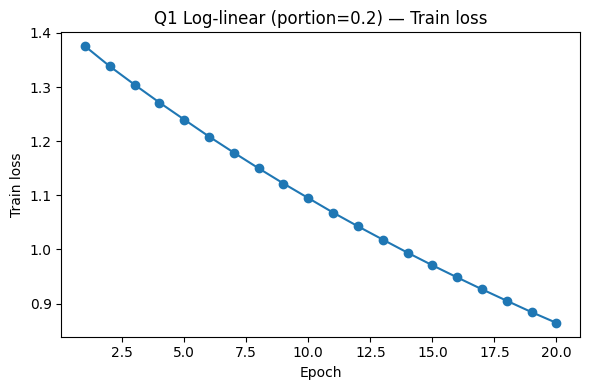

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_train_losses_b) + 1), q1_train_losses_b, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q1 Log-linear (portion=0.2) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


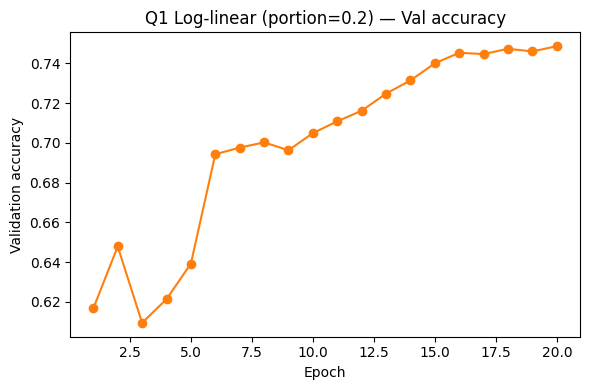

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_val_accs_b) + 1), q1_val_accs_b, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q1 Log-linear (portion=0.2) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q1 (c) portion=0.5

In [10]:
# Train log-linear (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q1_train_losses_c, q1_val_accs_c = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3760 | val acc 0.4927
Epoch 02 | train loss 1.3385 | val acc 0.5584
Epoch 03 | train loss 1.3043 | val acc 0.5358
Epoch 04 | train loss 1.2714 | val acc 0.5849
Epoch 05 | train loss 1.2390 | val acc 0.6034
Epoch 06 | train loss 1.2081 | val acc 0.6200
Epoch 07 | train loss 1.1783 | val acc 0.6691
Epoch 08 | train loss 1.1490 | val acc 0.6744
Epoch 09 | train loss 1.1205 | val acc 0.6883
Epoch 10 | train loss 1.0932 | val acc 0.7042
Epoch 11 | train loss 1.0668 | val acc 0.7115
Epoch 12 | train loss 1.0407 | val acc 0.7255
Epoch 13 | train loss 1.0158 | val acc 0.7301
Epoch 14 | train loss 0.9915 | val acc 0.7414
Epoch 15 | train loss 0.9680 | val acc 0.7440
Epoch 16 | train loss 0.9455 | val acc 0.7447
Epoch 17 | train loss 0.9232 | val acc 0.7480
Epoch 18 | train loss 0.9017 | val acc 0.7560
Epoch 19 | train loss 0.8811 | val acc 0.7593
Epoch 20 | train loss 0.8610 | val acc 0.7606


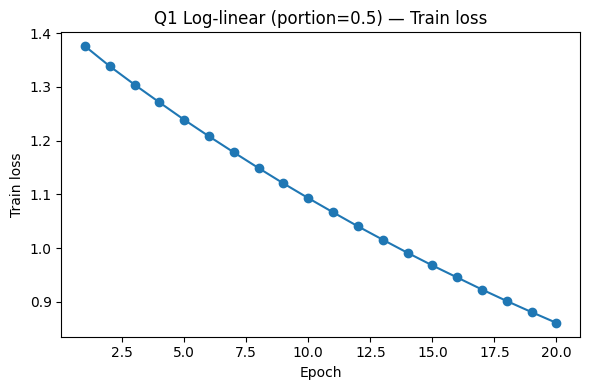

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_train_losses_c) + 1), q1_train_losses_c, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q1 Log-linear (portion=0.5) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


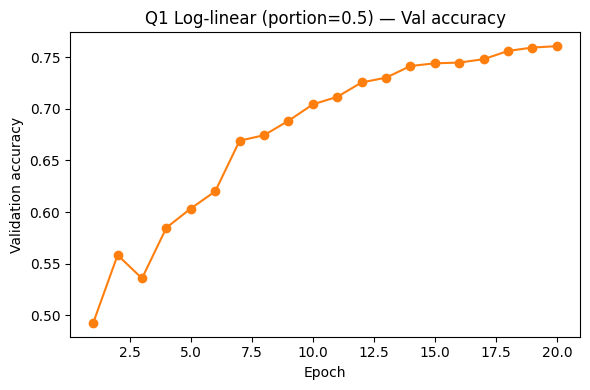

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_val_accs_c) + 1), q1_val_accs_c, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q1 Log-linear (portion=0.5) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q1 (d) portion=1.0

In [13]:
# Data + TFIDF (portion=1.0)
portion = 1.0
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 2267, test size: 1508


In [16]:
# Train log-linear (portion via cell above)
model = nn.Linear(feature_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q1_train_losses_d, q1_val_accs_d = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3351 | val acc 0.8203
Epoch 02 | train loss 1.2252 | val acc 0.8170
Epoch 03 | train loss 1.1281 | val acc 0.8309
Epoch 04 | train loss 1.0420 | val acc 0.8369
Epoch 05 | train loss 0.9656 | val acc 0.8389
Epoch 06 | train loss 0.8986 | val acc 0.8395
Epoch 07 | train loss 0.8387 | val acc 0.8422
Epoch 08 | train loss 0.7857 | val acc 0.8468
Epoch 09 | train loss 0.7386 | val acc 0.8428
Epoch 10 | train loss 0.6962 | val acc 0.8468
Epoch 11 | train loss 0.6582 | val acc 0.8468
Epoch 12 | train loss 0.6238 | val acc 0.8495
Epoch 13 | train loss 0.5926 | val acc 0.8481
Epoch 14 | train loss 0.5642 | val acc 0.8488
Epoch 15 | train loss 0.5381 | val acc 0.8475
Epoch 16 | train loss 0.5142 | val acc 0.8481
Epoch 17 | train loss 0.4922 | val acc 0.8495
Epoch 18 | train loss 0.4717 | val acc 0.8495
Epoch 19 | train loss 0.4527 | val acc 0.8515
Epoch 20 | train loss 0.4350 | val acc 0.8515


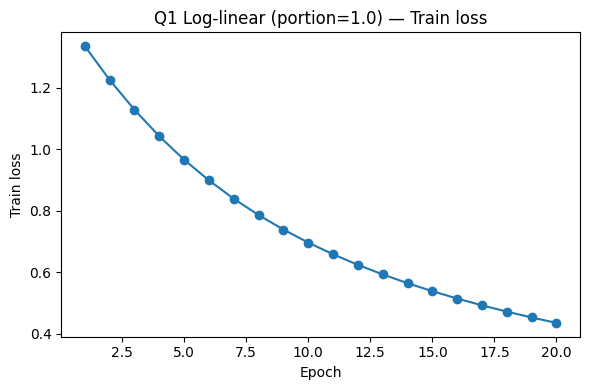

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_train_losses_d) + 1), q1_train_losses_d, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q1 Log-linear (portion=1.0) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


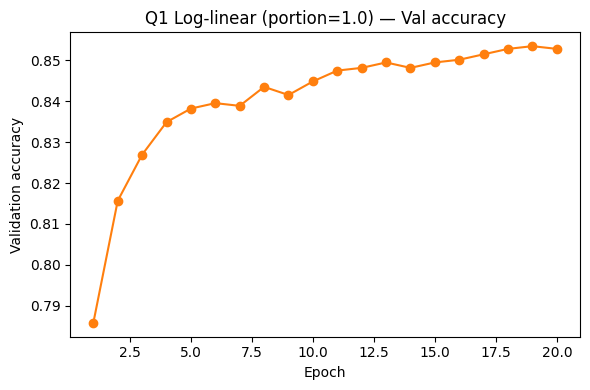

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q1_val_accs_d) + 1), q1_val_accs_d, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q1 Log-linear (portion=1.0) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


# Q2 — MLP classifier (TFIDF + one hidden layer, dim=500)

## Q2 (a) portion=0.1

In [17]:
# Data + TFIDF (portion=0.1)
portion = 0.1
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 229, test size: 1508


In [18]:
# Train MLP (portion via cell above)
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q2_train_losses_a, q2_val_accs_a = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3750 | val acc 0.5610
Epoch 02 | train loss 1.2621 | val acc 0.6233
Epoch 03 | train loss 1.0460 | val acc 0.7168
Epoch 04 | train loss 0.7295 | val acc 0.7454
Epoch 05 | train loss 0.4287 | val acc 0.7573
Epoch 06 | train loss 0.2330 | val acc 0.7580
Epoch 07 | train loss 0.1308 | val acc 0.7613
Epoch 08 | train loss 0.0793 | val acc 0.7639
Epoch 09 | train loss 0.0541 | val acc 0.7599
Epoch 10 | train loss 0.0403 | val acc 0.7599
Epoch 11 | train loss 0.0313 | val acc 0.7586
Epoch 12 | train loss 0.0255 | val acc 0.7566
Epoch 13 | train loss 0.0215 | val acc 0.7566
Epoch 14 | train loss 0.0184 | val acc 0.7533
Epoch 15 | train loss 0.0161 | val acc 0.7573
Epoch 16 | train loss 0.0144 | val acc 0.7493
Epoch 17 | train loss 0.0126 | val acc 0.7507
Epoch 18 | train loss 0.0114 | val acc 0.7500
Epoch 19 | train loss 0.0104 | val acc 0.7460
Epoch 20 | train loss 0.0093 | val acc 0.7487


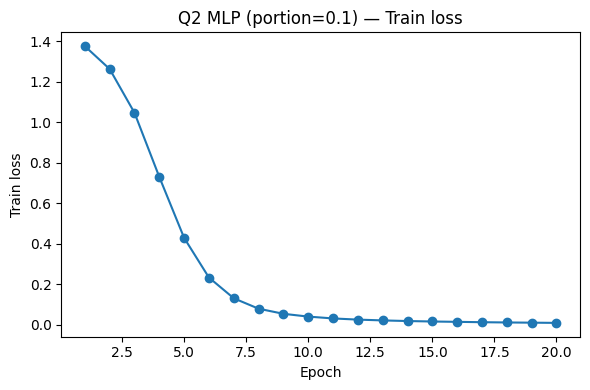

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_train_losses_a) + 1), q2_train_losses_a, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q2 MLP (portion=0.1) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


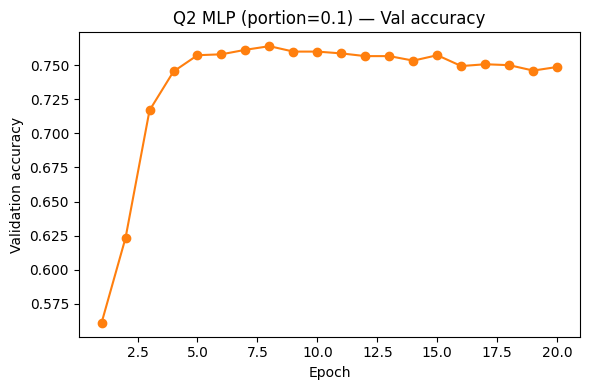

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_val_accs_a) + 1), q2_val_accs_a, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q2 MLP (portion=0.1) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q2 (b) portion=0.2

In [21]:
# Data + TFIDF (portion=0.2)
portion = 0.2
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 451, test size: 1508


In [22]:
# Train MLP (portion via cell above)
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q2_train_losses_b, q2_val_accs_b = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3431 | val acc 0.6558
Epoch 02 | train loss 1.0285 | val acc 0.7427
Epoch 03 | train loss 0.5470 | val acc 0.7997
Epoch 04 | train loss 0.2408 | val acc 0.8024
Epoch 05 | train loss 0.1172 | val acc 0.8037
Epoch 06 | train loss 0.0668 | val acc 0.8057
Epoch 07 | train loss 0.0438 | val acc 0.8070
Epoch 08 | train loss 0.0310 | val acc 0.8017
Epoch 09 | train loss 0.0241 | val acc 0.7984
Epoch 10 | train loss 0.0196 | val acc 0.7971
Epoch 11 | train loss 0.0164 | val acc 0.7944
Epoch 12 | train loss 0.0141 | val acc 0.7964
Epoch 13 | train loss 0.0123 | val acc 0.7964
Epoch 14 | train loss 0.0110 | val acc 0.7977
Epoch 15 | train loss 0.0099 | val acc 0.7984
Epoch 16 | train loss 0.0091 | val acc 0.7931
Epoch 17 | train loss 0.0083 | val acc 0.7944
Epoch 18 | train loss 0.0077 | val acc 0.7938
Epoch 19 | train loss 0.0071 | val acc 0.7938
Epoch 20 | train loss 0.0068 | val acc 0.7951


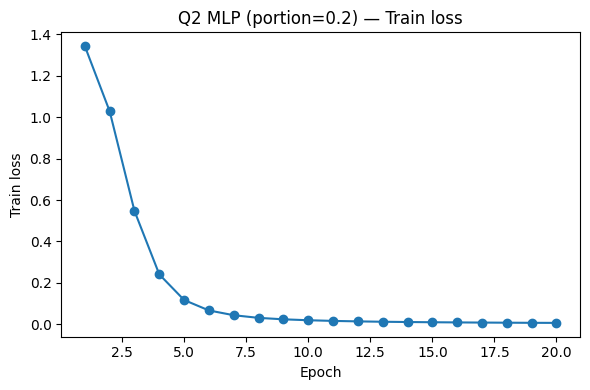

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_train_losses_b) + 1), q2_train_losses_b, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q2 MLP (portion=0.2) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


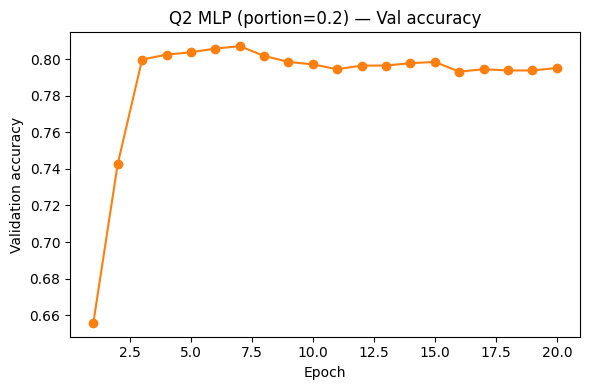

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_val_accs_b) + 1), q2_val_accs_b, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q2 MLP (portion=0.2) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q2 (c) portion=0.5

In [25]:
# Data + TFIDF (portion=0.5)
portion = 0.5
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 1133, test size: 1508


In [26]:
# Train MLP (portion via cell above)
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q2_train_losses_c, q2_val_accs_c = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.1825 | val acc 0.8044
Epoch 02 | train loss 0.4431 | val acc 0.8276
Epoch 03 | train loss 0.1632 | val acc 0.8302
Epoch 04 | train loss 0.0794 | val acc 0.8296
Epoch 05 | train loss 0.0437 | val acc 0.8276
Epoch 06 | train loss 0.0292 | val acc 0.8256
Epoch 07 | train loss 0.0224 | val acc 0.8223
Epoch 08 | train loss 0.0182 | val acc 0.8263
Epoch 09 | train loss 0.0160 | val acc 0.8249
Epoch 10 | train loss 0.0145 | val acc 0.8269
Epoch 11 | train loss 0.0133 | val acc 0.8223
Epoch 12 | train loss 0.0126 | val acc 0.8216
Epoch 13 | train loss 0.0121 | val acc 0.8210
Epoch 14 | train loss 0.0115 | val acc 0.8223
Epoch 15 | train loss 0.0115 | val acc 0.8216
Epoch 16 | train loss 0.0111 | val acc 0.8216
Epoch 17 | train loss 0.0108 | val acc 0.8196
Epoch 18 | train loss 0.0108 | val acc 0.8216
Epoch 19 | train loss 0.0110 | val acc 0.8190
Epoch 20 | train loss 0.0106 | val acc 0.8203


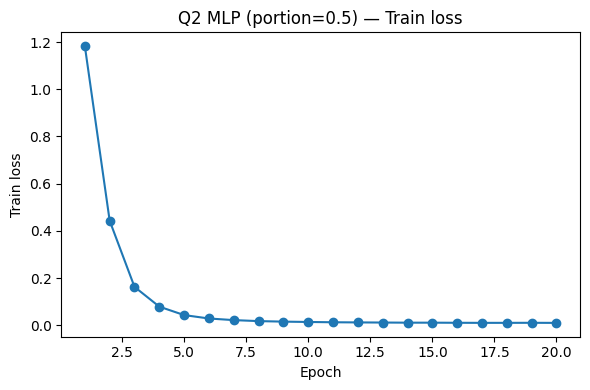

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_train_losses_c) + 1), q2_train_losses_c, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q2 MLP (portion=0.5) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


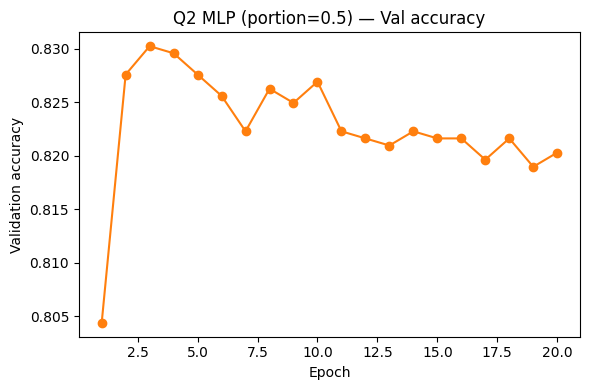

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_val_accs_c) + 1), q2_val_accs_c, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q2 MLP (portion=0.5) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q2 (d) portion=1.0

In [29]:
# Data + TFIDF (portion=1.0)
portion = 1.0
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 2267, test size: 1508


In [30]:
# Train MLP (portion via cell above)
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

q2_train_losses_d, q2_val_accs_d = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 0.8655 | val acc 0.8574
Epoch 02 | train loss 0.2222 | val acc 0.8508
Epoch 03 | train loss 0.0941 | val acc 0.8462
Epoch 04 | train loss 0.0502 | val acc 0.8375
Epoch 05 | train loss 0.0330 | val acc 0.8442
Epoch 06 | train loss 0.0248 | val acc 0.8395
Epoch 07 | train loss 0.0207 | val acc 0.8389
Epoch 08 | train loss 0.0190 | val acc 0.8389
Epoch 09 | train loss 0.0174 | val acc 0.8408
Epoch 10 | train loss 0.0167 | val acc 0.8389
Epoch 11 | train loss 0.0158 | val acc 0.8389
Epoch 12 | train loss 0.0160 | val acc 0.8395
Epoch 13 | train loss 0.0159 | val acc 0.8382
Epoch 14 | train loss 0.0150 | val acc 0.8355
Epoch 15 | train loss 0.0152 | val acc 0.8349
Epoch 16 | train loss 0.0147 | val acc 0.8375
Epoch 17 | train loss 0.0149 | val acc 0.8355
Epoch 18 | train loss 0.0152 | val acc 0.8355
Epoch 19 | train loss 0.0151 | val acc 0.8349
Epoch 20 | train loss 0.0153 | val acc 0.8322


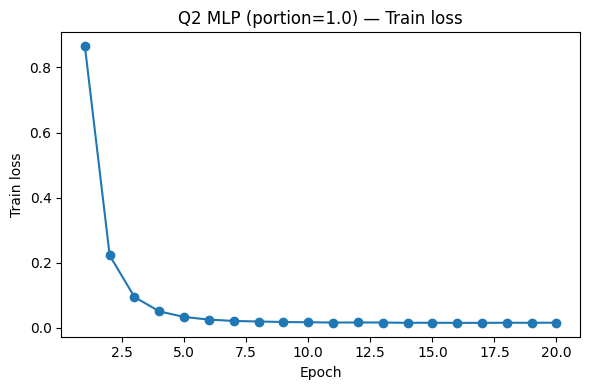

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_train_losses_d) + 1), q2_train_losses_d, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q2 MLP (portion=1.0) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


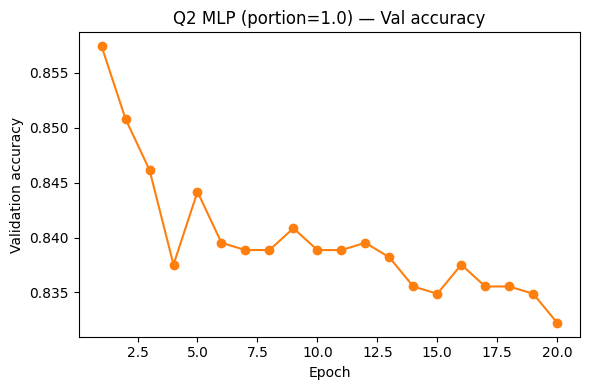

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q2_val_accs_d) + 1), q2_val_accs_d, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q2 MLP (portion=1.0) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


# Q3 — Fine-tune distilroberta-base (uses `transformer_classification` from ex2.py)

## Q3 (a) portion=0.1

In [33]:
# Q3 fine-tune (portion=0.1) — delegates to ex2.transformer_classification
q3_train_losses_a, q3_val_accs_a = transformer_classification(portion=0.1)


model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


100%|██████████| 95/95 [00:43<00:00,  2.20it/s]


Epoch 01 | train loss 1.2581 | val acc 0.8302


100%|██████████| 95/95 [00:41<00:00,  2.27it/s]


Epoch 02 | train loss 0.4375 | val acc 0.8568


100%|██████████| 95/95 [00:44<00:00,  2.14it/s]


Epoch 03 | train loss 0.1436 | val acc 0.8408


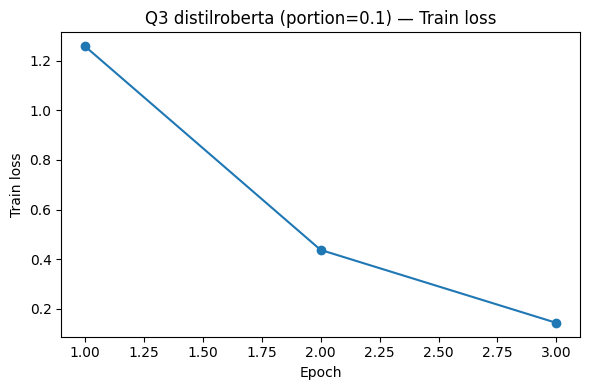

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q3_train_losses_a) + 1), q3_train_losses_a, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q3 distilroberta (portion=0.1) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


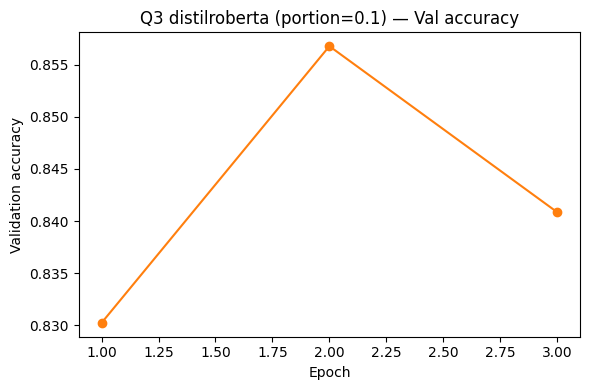

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q3_val_accs_a) + 1), q3_val_accs_a, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q3 distilroberta (portion=0.1) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## Q3 (b) portion=0.2

In [38]:
# Q3 fine-tune (portion=0.2) — delegates to ex2.transformer_classification
q3_train_losses_b, q3_val_accs_b = transformer_classification(portion=0.2)


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 95/95 [00:43<00:00,  2.17it/s]


Epoch 01 | train loss 0.8885 | val acc 0.8289


100%|██████████| 95/95 [00:46<00:00,  2.04it/s]


Epoch 02 | train loss 0.2929 | val acc 0.8528


100%|██████████| 95/95 [00:50<00:00,  1.87it/s]


Epoch 03 | train loss 0.2028 | val acc 0.8879


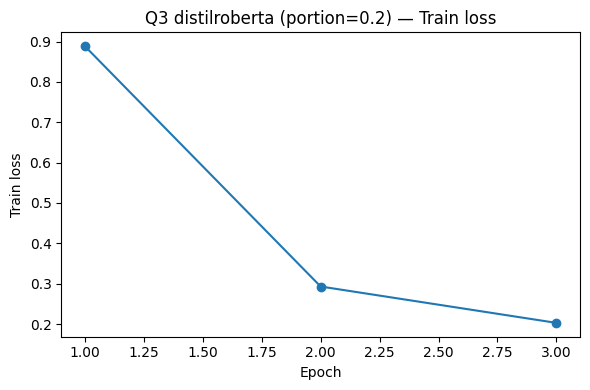

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q3_train_losses_b) + 1), q3_train_losses_b, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title('Q3 distilroberta (portion=0.2) — Train loss')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


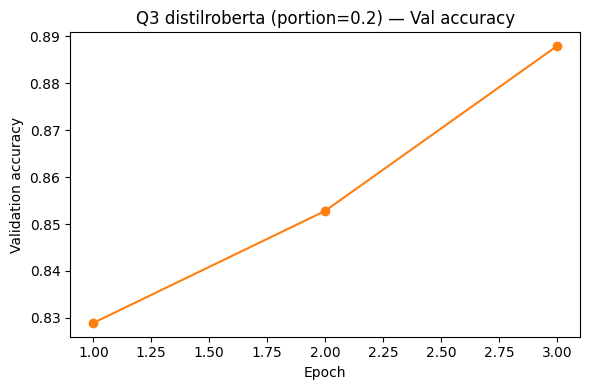

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(q3_val_accs_b) + 1), q3_val_accs_b, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title('Q3 distilroberta (portion=0.2) — Val accuracy')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


# Q4


## a
3b (transformers with 0.2 of the train set) had the highest test accuracy. 

## a
3b (transformers with 0.2 of the train set) had the highest test accuracy. 

## b

it seems the transformers one was most senstive, as the 0.1 one started overfitting immediately while the 0.2 is only accelerating at the 2nd epoch. after that it seems the MLP one was more sensitve (wierdly peaked earlier and thna started overfitting more the bigger the dataset is. we checked for a bug but could not find). 

# c

**Trainable parameters (extracted via `sum(p.numel() for p in model.parameters() if p.requires_grad)`):**                                                                                                                                      
                                                                                                                                                                                                                                               
  | Model | Trainable parameters |                                                                                                                                                                                                               
  |---|---:|                                                                                                                                                                                                                                     
  | Q1 (linear): (`Linear(2000, 4)`) | 8,004 |                                                                                                                                                                                                
  | Q2 (MLP): (`Linear(2000, 500) → ReLU → Linear(500, 4)`) | 1,002,504 |                                                                                                                                                                         
  | Q3  (transformer + classification head):| 82,121,476 |                                                                                                                                                                                 
                                                                                                                                                                                                                                                 
  **Do additional parameters help?**                                                                                                                                                                                                             
                                                                                                                                                                                                                                                 
  Yes (given enough data) but they bring an overfitting cost
                                                                                                                                                                                                                                                 
  - More parameters give the model more capacity to capture useful patterns, which is why the transformer (~82M) beats the MLP (~1M), which beats the log-linear (~8K) when each is given enough training examples.
  - The same extra capacity makes the model more prone to overfitting when data is scarce: the transformer at `portion=0.1` overfits within 2 epochs, while the log-linear barely overfits at all on the same data.                              
                                                                                                                                                                                                                                                 
  In short: **more parameters → higher peak accuracy, but higher sensitivity to training-set size.**

